# NREL quickstart — NSRDB solar + WIND Toolkit (live)

The `nrel` backend fetches **solar and wind resource time series** from the
US NREL/NLR [Developer Network](https://developer.nlr.gov/) keyed CSV download
API. Unlike the keyless backends it needs a **free API key + the email that
registered it** (`api_key=` / `email=`, or the `NREL_API_KEY` / `NREL_EMAIL`
environment variables) — register at <https://developer.nlr.gov/signup/>.

This notebook pulls one year of **hourly** NSRDB solar data and one year of
**WIND Toolkit** wind data for a single point (Denver, Colorado) and inspects
the returned `pandas.DataFrame`s.

In [1]:
import os
import tempfile

import pandas as pd
import matplotlib.pyplot as plt

from earthlens.earthlens import EarthLens

# Credentials come from the environment; they are never printed.
API_KEY = os.environ["NREL_API_KEY"]
EMAIL = os.environ["NREL_EMAIL"]

OUT = tempfile.mkdtemp()  # downloads also write a CSV here

## Download one year of NSRDB hourly solar

`data_source="nrel"` uses the default `nsrdb-psm3` product (NSRDB GOES
Aggregated PSM v4). `variables=` lists the attributes; a single
`point=(lat, lon)` over one year is one keyed CSV call. `download()` returns
the hourly table and writes it to `path` as CSV.

In [2]:
solar = EarthLens(
    data_source="nrel",
    variables=["ghi", "dni", "dhi", "air_temperature"],
    start="2020-01-01",
    end="2020-12-31",
    point=(39.74, -105.18),     # Denver, Colorado
    api_key=API_KEY,
    email=EMAIL,
    path=OUT,
).download(progress_bar=False)

print(solar.shape)
solar.head()

2026-06-27 02:34:30.317 | INFO     | earthlens.nrel.backend:download:374 - NREL nsrdb-psm3: 8760 row(s) -> C:\Users\main\AppData\Local\Temp\tmp8l75ft60\nrel_nsrdb-psm3.csv


2026-06-27 02:34:30.318 | INFO     | earthlens.nrel.backend:download:375 - Data from the NREL National Solar Radiation Database (NSRDB) / WIND Toolkit via the NREL Developer Network (developer.nlr.gov). Please cite NREL per https://nsrdb.nrel.gov/ and the WIND Toolkit references.


(8760, 14)


,Year,Month,Day,Hour,Minute,GHI,DNI,DHI,Temperature,time,lat,lon,year,product
0,2020,1,1,0,30,0,0,0,-3.2,2020-01-01 00:30:00,39.74,-105.18,2020,nsrdb-psm3
1,2020,1,1,1,30,0,0,0,-2.9,2020-01-01 01:30:00,39.74,-105.18,2020,nsrdb-psm3
2,2020,1,1,2,30,0,0,0,-2.7,2020-01-01 02:30:00,39.74,-105.18,2020,nsrdb-psm3
3,2020,1,1,3,30,0,0,0,-2.5,2020-01-01 03:30:00,39.74,-105.18,2020,nsrdb-psm3
4,2020,1,1,4,30,0,0,0,-2.3,2020-01-01 04:30:00,39.74,-105.18,2020,nsrdb-psm3


Each row is one hour. `GHI` / `DNI` / `DHI` are the global / direct / diffuse
irradiance components (W/m²), `Temperature` the air temperature (°C); the
`lat` / `lon` / `year` / `product` columns tag the sampled point. The `time`
column is assembled from the CSV's Year/Month/Day/Hour/Minute fields.

In [3]:
solar.dtypes

Year                    int64
Month                   int64
Day                     int64
Hour                    int64
Minute                  int64
GHI                     int64
DNI                     int64
DHI                     int64
Temperature           float64
time           datetime64[us]
lat                   float64
lon                   float64
year                    int64
product                   str
dtype: object

## Plot a few days of irradiance

A short summer window shows the diurnal cycle of `GHI`.

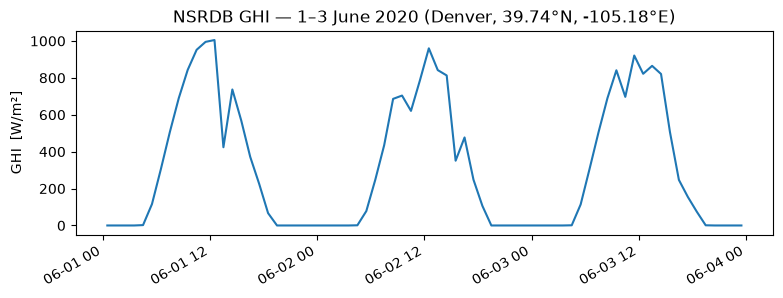

In [4]:
window = solar[(solar["time"] >= "2020-06-01") & (solar["time"] < "2020-06-04")]

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(window["time"], window["GHI"])
ax.set_ylabel("GHI  [W/m²]")
ax.set_title("NSRDB GHI — 1–3 June 2020 (Denver, 39.74°N, -105.18°E)")
fig.autofmt_xdate()
plt.show()

## Download WIND Toolkit hourly wind

The `"wind-toolkit"` alias selects the WTK product (`product="wtk"`). WTK
attributes are per hub height (`windspeed_100m`, `winddirection_100m`, …); the
CONUS archive covers roughly 2007–2014.

In [5]:
wind = EarthLens(
    data_source="wind-toolkit",
    variables=["windspeed_100m", "winddirection_100m", "temperature_100m"],
    start="2012-01-01",
    end="2012-12-31",
    point=(39.74, -105.18),
    api_key=API_KEY,
    email=EMAIL,
    path=OUT,
).download(progress_bar=False)

print(wind.shape)
wind.head()

2026-06-27 02:34:34.504 | INFO     | earthlens.nrel.backend:download:374 - NREL wtk: 8760 row(s) -> C:\Users\main\AppData\Local\Temp\tmp8l75ft60\nrel_wtk.csv


2026-06-27 02:34:34.506 | INFO     | earthlens.nrel.backend:download:375 - Data from the NREL National Solar Radiation Database (NSRDB) / WIND Toolkit via the NREL Developer Network (developer.nlr.gov). Please cite NREL per https://nsrdb.nrel.gov/ and the WIND Toolkit references.


(8760, 13)


,Year,Month,Day,Hour,Minute,wind speed at 100m (m/s),wind direction at 100m (deg),air temperature at 100m (C),time,lat,lon,year,product
0,2012,1,1,0,30,8.44,173.99,-3.43,2012-01-01 00:30:00,39.74,-105.18,2012,wtk
1,2012,1,1,1,30,8.33,170.17,-3.35,2012-01-01 01:30:00,39.74,-105.18,2012,wtk
2,2012,1,1,2,30,6.77,181.08,-2.71,2012-01-01 02:30:00,39.74,-105.18,2012,wtk
3,2012,1,1,3,30,2.89,165.41,-0.86,2012-01-01 03:30:00,39.74,-105.18,2012,wtk
4,2012,1,1,4,30,1.57,122.59,-1.93,2012-01-01 04:30:00,39.74,-105.18,2012,wtk


## Inspect the product catalog

The bundled catalog maps each product id to its source, endpoint, default
attributes, and columns. Select a product with `product=` or the
`nsrdb` / `wind-toolkit` facade aliases.

In [6]:
from earthlens.nrel import Catalog

catalog = Catalog()
print(catalog.available())
catalog.get("nsrdb-psm3")

['nsrdb-psm3', 'nsrdb-tmy', 'wtk']


Product(source='nsrdb', endpoint='/api/nsrdb/v2/solar/nsrdb-GOES-aggregated-v4-0-0-download.csv', names_kind='year', default_attributes=['ghi', 'dni', 'dhi', 'air_temperature', 'wind_speed'], interval=60, meta_rows=2, columns=['time', 'GHI', 'DNI', 'DHI', 'Temperature', 'Wind Speed'], description='NSRDB GOES Aggregated PSM v4 — hourly satellite-derived solar resource (global/direct/diffuse horizontal irradiance) plus meteorology, for one point and one year (valid years 1998-2024). The current replacement for the retired PSM v3.2.2 hourly product.')

## Takeaway

One keyed call per `(point, year)` returns a tidy hourly `DataFrame` you can
resample or plot directly. NREL already returns the resolved hourly / TMY
series, so the facade rejects `aggregate=`; use pandas
(`df.set_index("time").resample("1D").mean()`) for a coarser cadence. The CSV
API is rate-limited (≤1 req/s, 5000/day), so a bbox × multi-year request fans
out into many throttled calls — coarsen `spacing_deg` or narrow the years.